![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 01 | Exploratory Data Analysis

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

Understanding your data before you design anything. You cannot decide which tables you need until you know which columns repeat, which are broken, and which identify a row.

> **Done when:** you can name the 3+ tables you are going to build, you have written down at least 2 research questions, and you know every data-quality problem notebook 02 will have to fix.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [1]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

---
## 1. Load the raw data

Run `python download_data.py <payments|airbnb|retail>` from the repo root first. Your files land in `data/raw/`, which is gitignored.

In [4]:
import os
os.listdir("../data/raw/")

['FAOSTAT_data_en_9-25-2026.csv',
 'FAOSTAT_data_en_9-25-2026 (2).csv',
 '.gitkeep',
 'FAOSTAT_data_en_9-25-2026 (1).csv']

In [5]:
RAW = "../data/raw/"

production = pd.read_csv(RAW + "FAOSTAT_data_en_9-25-2026.csv", encoding="utf-8-sig")
trade      = pd.read_csv(RAW + "FAOSTAT_data_en_9-25-2026 (1).csv", encoding="utf-8-sig")
processed  = pd.read_csv(RAW + "FAOSTAT_data_en_9-25-2026 (2).csv", encoding="utf-8-sig")

print("production:", production.shape)
print("trade:     ", trade.shape)
print("processed: ", processed.shape)

production: (15622, 15)
trade:      (40306, 15)
processed:  (1421, 15)


---
## 2. First look

Shape, column types, a handful of rows. What is one row of this data?

In [13]:
production.head()
trade.head()
processed.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,SCL,Supply Utilization Accounts (2010-),8,Albania,5023,Processed,1610,"Coffee, green",2010,2010,t,4642.00,E,Estimated value,NaN
1,SCL,Supply Utilization Accounts (2010-),8,Albania,5023,Processed,1610,"Coffee, green",2011,2011,t,4922.00,E,Estimated value,NaN
2,SCL,Supply Utilization Accounts (2010-),8,Albania,5023,Processed,1610,"Coffee, green",2012,2012,t,5189.00,E,Estimated value,NaN
3,SCL,Supply Utilization Accounts (2010-),8,Albania,5023,Processed,1610,"Coffee, green",2013,2013,t,5216.00,E,Estimated value,NaN
4,SCL,Supply Utilization Accounts (2010-),8,Albania,5023,Processed,1610,"Coffee, green",2014,2014,t,4199.23,E,Estimated value,NaN


---
## 3. Data quality

Missing values, duplicates, numbers stored as text, dates stored as strings. Write down what you find — this is the to-do list for notebook 02.

In [12]:
production.isna().sum()
trade.isna().sum()
processed.isna().sum()

Domain Code            0
Domain                 0
Area Code (M49)        0
Area                   0
Element Code           0
Element                0
Item Code (CPC)        0
Item                   0
Year Code              0
Year                   0
Unit                   0
Value                  0
Flag                   0
Flag Description       0
Note                1421
dtype: int64

In [9]:
production.duplicated().sum()

np.int64(0)

---
## 4. Distributions

The numeric columns you care about, and the outliers you will have to decide about.

In [14]:
production.groupby("Element")["Value"].describe()

,count,mean,std,min,25%,50%,75%,max
Element,,,,,,,,
Area harvested,5157.0,127994.809385,328732.851285,0.0,730.00,14242.0,113443.00,4462657.0
Production,5191.0,82272.231476,268012.121301,0.0,362.38,7140.0,56998.50,3705719.0
Yield,5007.0,653.497184,589.043416,5.6,319.00,509.0,830.35,13333.3


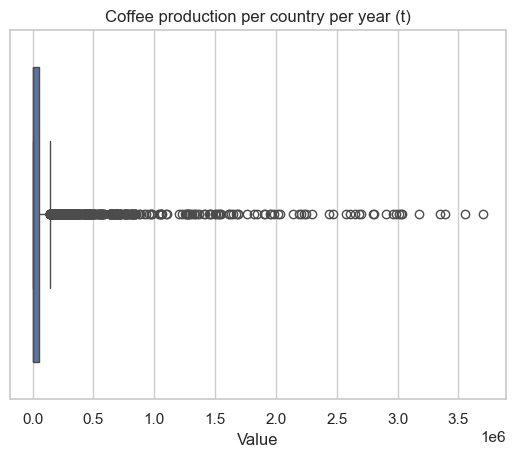

In [18]:
prod_only = production[production["Element"] == "Production"]
sns.boxplot(x=prod_only["Value"])
plt.title("Coffee production per country per year (t)")
plt.show()

In [21]:
trade.groupby("Element")["Value"].describe()

,count,mean,std,min,25%,50%,75%,max
Element,,,,,,,,
Export quantity,9240.0,34621.191444,144180.171069,0.0,0.5275,249.055,7891.25,2768767.08
Export value,9279.0,77818.022093,367110.430431,0.0,2.0000,529.000,14970.50,11337478.00
Import quantity,10859.0,29030.966537,123144.815032,0.0,2.0000,154.000,9640.50,1592249.37
Import value,10928.0,71256.061951,343988.303000,0.0,7.0000,289.000,15447.00,7888644.00


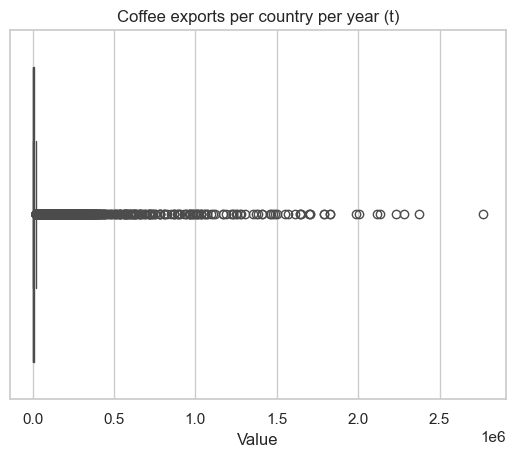

In [22]:
exports = trade[trade["Element"] == "Export quantity"]
sns.boxplot(x=exports["Value"])
plt.title("Coffee exports per country per year (t)")
plt.show()

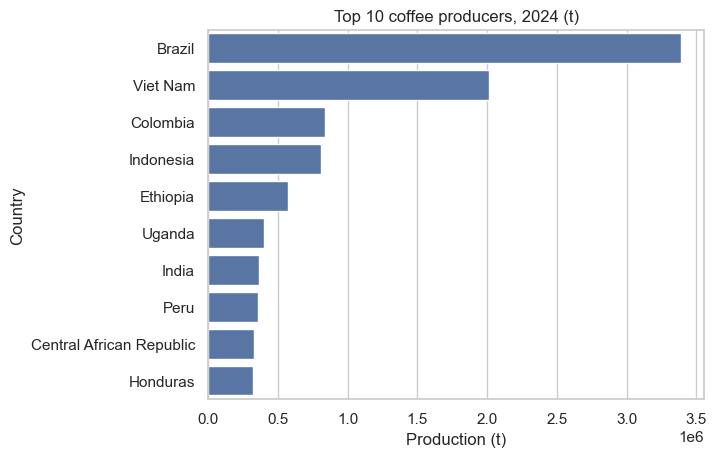

In [20]:
top10 = prod_only[prod_only["Year"] == 2024].nlargest(10, "Value")

sns.barplot(data=top10, x="Value", y="Area")
plt.title("Top 10 coffee producers, 2024 (t)")
plt.xlabel("Production (t)")
plt.ylabel("Country")
plt.show()

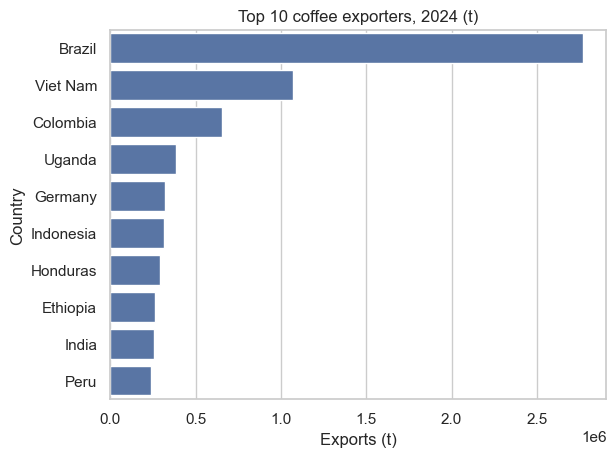

In [23]:
top10_exp = exports[exports["Year"] == 2024].nlargest(10, "Value")

sns.barplot(data=top10_exp, x="Value", y="Area")
plt.title("Top 10 coffee exporters, 2024 (t)")
plt.xlabel("Exports (t)")
plt.ylabel("Country")
plt.show()

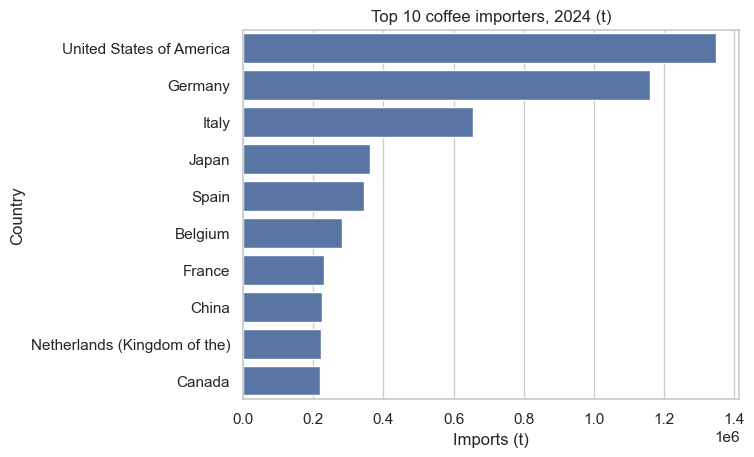

In [24]:
imports = trade[trade["Element"] == "Import quantity"]
top10_imp = imports[imports["Year"] == 2024].nlargest(10, "Value")

sns.barplot(data=top10_imp, x="Value", y="Area")
plt.title("Top 10 coffee importers, 2024 (t)")
plt.xlabel("Imports (t)")
plt.ylabel("Country")
plt.show()

---
## 5. Categorical columns

**This is the section that feeds tomorrow.** A column with few distinct values repeated over many rows is a lookup table waiting to happen. Find them.

In [28]:
for name, df in {"production": production, "trade": trade, "processed": processed}.items():
    print(f"{name} ({len(df):,} rows)")
    print(df.nunique().sort_values())
    print()

production (15,622 rows)
Domain Code            1
Domain                 1
Item Code (CPC)        1
Item                   1
Note                   1
Element Code           3
Element                3
Unit                   3
Flag                   5
Flag Description       5
Year Code             64
Year                  64
Area Code (M49)       86
Area                  86
Value               9399
dtype: int64

trade (40,306 rows)
Domain Code             1
Domain                  1
Item Code (CPC)         1
Item                    1
Note                    1
Unit                    2
Element Code            4
Element                 4
Flag                    4
Flag Description        4
Year Code              64
Year                   64
Area Code (M49)       206
Area                  206
Value               17073
dtype: int64

processed (1,421 rows)
Note                   0
Domain Code            1
Domain                 1
Element Code           1
Element                1
Item Code (CPC

---
## 6. Research questions

At least two, written here. Specific, answerable with this data, and with an answer you could be wrong about. For each one, say what you expect and why.

1. IWW can data analytics and forecasting models, built on historical production, area, yield and trade data, help predict future coffee supply and export flows?How might we help farmers produce more coffee from existing land in a sustainable way?
2. How might we help farmers produce more coffee from existing land in a sustainable way?

---
## 7. Into notebook 02

The tables you are going to build, and the problems you have to fix first.